# Exercises

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.power as smp
import statsmodels.stats.proportion as smprop
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

---
## Exercise 2.9 Continuous random variable

### a)
The following Python commands and results are given:
```python
print(stats.norm.cdf(2))
0.9772498680518208
print(stats.norm.cdf(2,1,1))
0.8413447460685429
print(stats.norm.cdf(2,1,2))
0.6914624612740131
```
Specify which distributions are used and explain the resulting probabilities (preferably by a sketch).

**Solution:**

All three calls use the CDF of the normal distribution. `scipy.stats.norm` defaults to $\mathcal{N}(0, 1)$ when no `loc`/`scale` are given.

- `norm.cdf(2)` → $\mathcal{N}(0, 1)$: $P(X \leq 2) \approx 97.7\%$. $x=2$ is $2\sigma$ above the mean.
- `norm.cdf(2, 1, 1)` → $\mathcal{N}(1, 1^2)$: $P(X \leq 2) \approx 84.1\%$. $x=2$ is only $1\sigma$ above the mean.
- `norm.cdf(2, 1, 2)` → $\mathcal{N}(1, 2^2)$: $P(X \leq 2) \approx 69.1\%$. Wider spread, so less probability mass is below $x=2$.

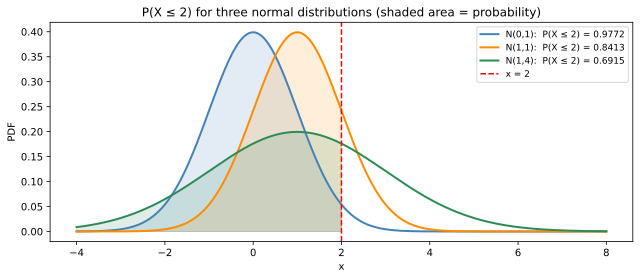

In [2]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.linspace(-4, 8, 500)

dists = [
    (stats.norm(0, 1), 'N(0,1)',  0.9772),
    (stats.norm(1, 1), 'N(1,1)',  0.8413),
    (stats.norm(1, 2), 'N(1,4)',  0.6915),
]
colors = ['steelblue', 'darkorange', 'seagreen']

for (dist, label, prob), color in zip(dists, colors):
    ax.plot(x, dist.pdf(x), color=color, lw=2, label=f'{label}:  P(X ≤ 2) = {prob}')
    xf = np.linspace(-4, 2, 300)
    ax.fill_between(xf, dist.pdf(xf), alpha=0.15, color=color)

ax.axvline(2, color='red', linestyle='--', lw=1.5, label='x = 2')
ax.set_xlabel('x')
ax.set_ylabel('PDF')
ax.set_title('P(X ≤ 2) for three normal distributions (shaded area = probability)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### b)
What is the result of the following command: `stats.norm.ppf(stats.norm.cdf(2))`?

**Solution:**

`ppf` is the inverse of `cdf`, so `ppf(cdf(2)) = 2.0`. They undo each other.

In [3]:
print(stats.norm.ppf(stats.norm.cdf(2)))

2.0


### c)
The following Python commands and results are given:
```python
print(stats.norm.ppf(0.975))
1.959963984540054
print(stats.norm.ppf(0.975,1,1))
2.959963984540054
print(stats.norm.ppf(0.975,1,2))
4.919927969080108
```
State what the numbers represent in the three cases (preferably by a sketch).

**Solution:**

`ppf(0.975)` gives the $x$-value with 97.5% of the distribution to its left the 97.5th percentile.

The pattern follows $x = \mu + z \cdot \sigma$ where $z = \Phi^{-1}(0.975) = 1.96$:
- $\mathcal{N}(0,1)$: $x = 0 + 1.96 \cdot 1 = 1.96$
- $\mathcal{N}(1,1)$: $x = 1 + 1.96 \cdot 1 = 2.96$
- $\mathcal{N}(1,4)$: $x = 1 + 1.96 \cdot 2 = 4.92$

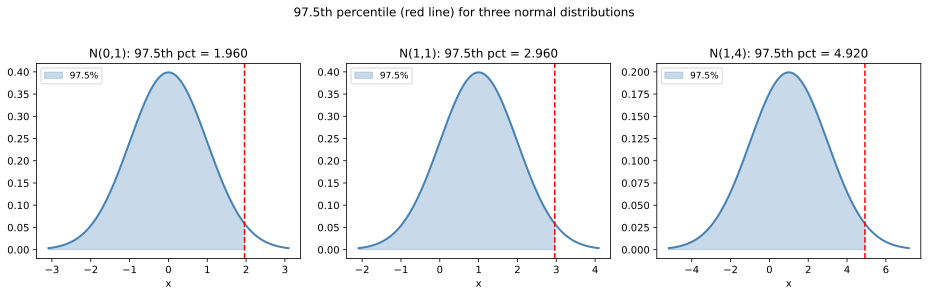

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
params = [(0, 1), (1, 1), (1, 2)]

for ax, (mu, sig) in zip(axes, params):
    dist = stats.norm(mu, sig)
    q = dist.ppf(0.975)
    xp = np.linspace(dist.ppf(0.001), dist.ppf(0.999), 400)
    ax.plot(xp, dist.pdf(xp), 'steelblue', lw=2)
    xf = np.linspace(xp[0], q, 300)
    ax.fill_between(xf, dist.pdf(xf), alpha=0.3, color='steelblue', label='97.5%')
    ax.axvline(q, color='red', linestyle='--', lw=1.5)
    ax.set_title(f'N({mu},{sig**2}): 97.5th pct = {q:.3f}')
    ax.set_xlabel('x')
    ax.legend(fontsize=9)

plt.suptitle('97.5th percentile (red line) for three normal distributions', y=1.02)
plt.tight_layout()
plt.show()

---
## Exercise 2.10 The normal pdf

### a)
Which of the following statements regarding the probability density function of the normal distribution $\mathcal{N}(1, 2^2)$ is false?

1. The total area under the curve is equal to 1.0
2. The mean is equal to $1^2$
3. The variance is equal to 2
4. The curve is symmetric about the mean
5. The two tails of the curve extend indefinitely
6. Don't know

**Solution:**

Statement **3** is false: $\mathcal{N}(1, 2^2)$ has variance $= 4$, not $2$. The notation $\mathcal{N}(\mu, \sigma^2)$ means $\sigma^2 = 4$, $\sigma = 2$.

### b)
Let $X$ be normally distributed with mean 24 and variance 16. Calculate the following probabilities:

- $P(X \leq 20)$
- $P(X > 29.5)$
- $P(X = 23.8)$

**Solution:**

Standardizing: $Z = (X - \mu)/\sigma$ where $\sigma = \sqrt{16} = 4$.

- $P(X \leq 20)$: $Z = (20-24)/4 = -1.0 \Rightarrow \Phi(-1) \approx 0.1587$
- $P(X > 29.5)$: $Z = (29.5-24)/4 = 1.375 \Rightarrow 1 - \Phi(1.375) \approx 0.0846$
- $P(X = 23.8) = 0$: for any continuous distribution, $P(X = x) = 0$, this is always the case.

In [5]:
x = stats.norm(loc=24, scale=np.sqrt(16))
print(x.cdf(20))        # P(X <= 20)
print(1 - x.cdf(29.5))  # P(X > 29.5)
print(0)                 # P(X = 23.8) = 0

0.15865525393145707
0.08456572235133564
0


---
## Exercise 2.11 Computer chip control

A machine for checking computer chips uses on average 65 milliseconds per check with a standard deviation of 4 milliseconds. A newer machine, potentially to be bought, uses on average 54 milliseconds per check with a standard deviation of 3 milliseconds. It can be used that check times can be assumed normally distributed and independent.

### a)
What is the probability that the time savings per check using the new machine is less than 10 milliseconds?

**Solution:**

Define $D = X_{\text{old}} - X_{\text{new}}$. Since both are independent normals, variances add:

$$D \sim \mathcal{N}(65 - 54,\ 4^2 + 3^2) = \mathcal{N}(11, 25)$$

In [6]:
old_avg, old_std = 65, 4
new_avg, new_std = 54, 3

D = stats.norm(loc=old_avg - new_avg, scale=np.sqrt(old_std**2 + new_std**2))
print(D.cdf(10))

0.42074029056089696


### b)
What is the mean ($\mu$) and standard deviation ($\sigma$) for the total time use for checking 100 chips on the new machine?

**Solution:**

Let $T = \sum_{i=1}^{100} X_i$ where each $X_i \sim \mathcal{N}(54, 9)$ independently:

$$\mu_T = 100 \cdot 54 = 5400 \text{ ms}$$

$$\sigma_T = \sqrt{\sum_{i=1}^{100} \sigma_i^2} = \sqrt{100 \cdot 9} = \sqrt{900} = 30 \text{ ms}$$

---
## Exercise 2.12 Concrete items

A manufacturer of concrete items knows that the length ($L$) of his items are reasonably normally distributed with $\mu_L = 3000$ mm and $\sigma_L = 3$ mm. The requirement for these elements is that the length should be not more than 3007 mm and the length must be at least 2993 mm.

### a)
The expected error rate in the manufacturing will be?

**Solution:**

Error rate $= P(L < 2993) + P(L > 3007)$. By symmetry $= 2 \cdot \Phi\left(\frac{2993 - 3000}{3}\right) = 2 \cdot \Phi(-2.33)$.

In [7]:
L = stats.norm(loc=3000, scale=3)
error_rate = L.cdf(2993) + (1 - L.cdf(3007))
print(error_rate)  # ≈ 0.0196 → ~2% error rate

0.01963065725729065


### b)
The concrete items are supported by beams, where the distance between the beams is called $L_{\text{beam}}$ and can be assumed normal distributed. The concrete items length is still called $L$. For the items to be supported correctly, the following requirements for these lengths must be fulfilled: $90 \text{ mm} < L - L_{\text{beam}} < 110 \text{ mm}$. It is assumed that the mean of the distance between the beams is $\mu_{\text{beam}} = 2900$ mm. How large may the standard deviation $\sigma_{\text{beam}}$ of the distance between the beams be if you want the requirement fulfilled in 99% of the cases?

**Solution:**

Define $D = L - L_{\text{beam}}$. Since $L$ and $L_{\text{beam}}$ are independent:

$$D \sim \mathcal{N}(3000 - 2900,\ 3^2 + \sigma_{\text{beam}}^2) = \mathcal{N}(100,\ 9 + \sigma_{\text{beam}}^2)$$

Need $P(90 < D < 110) = 0.99$. The bounds are symmetric around $\mu_D = 100$, so each tail holds $0.5\%$. The upper bound has $99.5\%$ to its left: $z = \Phi^{-1}(0.995) = 2.576$.

From $Z = (x - \mu)/\sigma_D$ rearranged:
$$\sigma_D = \frac{110 - 100}{z} = \frac{10}{2.576}$$

Then from $\sigma_D^2 = \sigma_L^2 + \sigma_{\text{beam}}^2$:
$$\sigma_{\text{beam}} = \sqrt{\sigma_D^2 - 9}$$

In [8]:
z = stats.norm.ppf(0.995)
sigma_D = 10 / z                   # rearrange Z = (x - mu) / sigma
sigma_beam = np.sqrt(sigma_D**2 - 3**2)

print(f"sigma_D    = {sigma_D:.4f} mm")
print(f"sigma_beam = {sigma_beam:.4f} mm")

sigma_D    = 3.8822 mm
sigma_beam = 2.4641 mm


---
## Exercise 2.13 Online statistic video views

In 2013, there were 110,000 views of the DTU statistics videos that are available online. Assume first that the occurrence of views through 2014 follows a Poisson process with a 2013 average: $\lambda_{365\text{ days}} = 110000$.

### a)
What is the probability that in a randomly chosen half an hour there is no occurrence of views?

**Solution:**

Scale $\lambda$ to 30 minutes: $\lambda_{30} = \frac{110000}{365 \cdot 24 \cdot 2}$

For Poisson, $P(X = 0) = e^{-\lambda}$ (since $\lambda^0 / 0! = 1$).

In [9]:
lam_year = 110000
lam_30 = ((lam_year / 365) / 24) / 2  # scale to 30-minute window

P_zero = np.exp(-lam_30)
print(f"lambda_30 = {lam_30:.4f}")
print(f"P(X=0)    = {P_zero:.6f}")

lambda_30 = 6.2785
P(X=0)    = 0.001876


### b)
There has just been a view, what is the probability that you have to wait more than fifteen minutes for the next view?

**Solution:**

Waiting times between Poisson events follow the **Exponential distribution**. For $T \sim \text{Exp}(\lambda)$:

$$P(T > t) = e^{-\lambda t}$$

Using $\lambda_{15} = \lambda_{30} / 2$ (scaling to a 15-minute window):

$$P(T > 15\text{ min}) = e^{-\lambda_{15}}$$

In [10]:
lam_15 = lam_30 / 2
P_wait = np.exp(-lam_15)
print(f"P(wait > 15 min) = {P_wait:.6f}")  # ≈ 0.0433

P(wait > 15 min) = 0.043314
